### Phase 7: Evaluation

In this phase, the results obtained from the generalization phase are analyzed to evaluate the reliability, stability, and robustness of the causal inference pipeline.

The evaluation is performed using statistical measures, consistency checks, and validation through refutation results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [2]:
results_df = pd.read_csv("../results/phase6/generalization_results.csv")
results_df.index = ["education", "healthcare", "marketing"]
results_df = results_df.round(4)
results_df

,ATE,CF_effect,Bootstrap_mean,Bootstrap_std
education,0.534,0.01,0.0173,0.0564
healthcare,0.007,0.00,-0.0023,0.0056
marketing,0.005,0.00,0.0000,0.0000


### Loading Results

The results generated from the generalization phase are loaded for analysis.

These results contain the estimated causal effects, counterfactual effects, and bootstrap statistics for each dataset.

In [3]:
print("Summary Statistics:")
display(results_df.describe())

Summary Statistics:


,ATE,CF_effect,Bootstrap_mean,Bootstrap_std
count,3.000000,3.000000,3.000000,3.000000
mean,0.182000,0.003333,0.005000,0.020667
std,0.304843,0.005774,0.010714,0.031072
min,0.005000,0.000000,-0.002300,0.000000
25%,0.006000,0.000000,-0.001150,0.002800
50%,0.007000,0.000000,0.000000,0.005600
75%,0.270500,0.005000,0.008650,0.031000
max,0.534000,0.010000,0.017300,0.056400


### Summary Statistics

Statistical summary is computed to understand the distribution of the estimated values.

This includes measures such as mean, standard deviation, minimum, and maximum, providing an overview of the results across datasets.

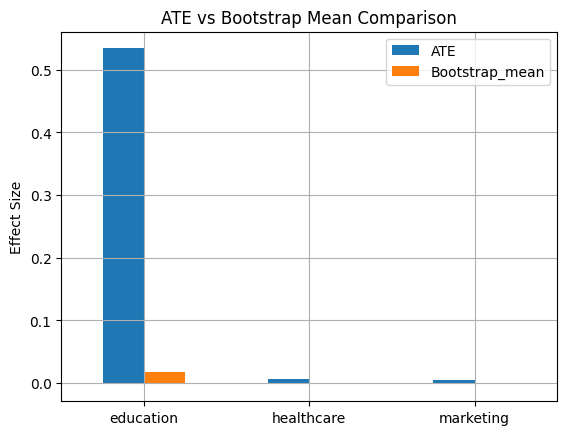

In [4]:
results_df[["ATE", "Bootstrap_mean"]].plot(kind = "bar")
plt.title("ATE vs Bootstrap Mean Comparison")
plt.ylabel("Effect Size")
plt.xticks(rotation = 0)
plt.grid(True)
plt.show()

### Effect Comparison

The comparison between Average Treatment Effect (ATE) and Bootstrap Mean highlights differences in estimated causal effects.

Variations between these values indicate how sensitive the model is to sampling and estimation methods.

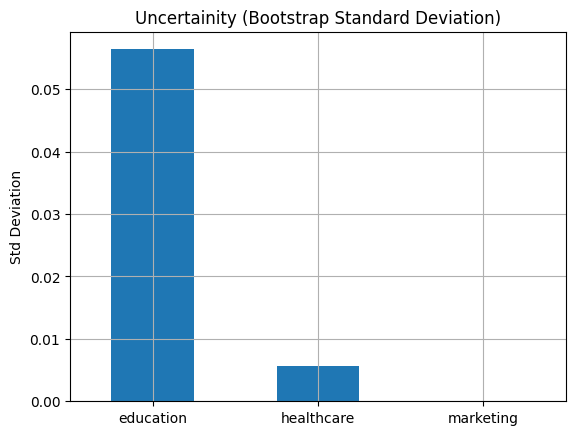

In [5]:
results_df["Bootstrap_std"].plot(kind = "bar")
plt.title("Uncertainity (Bootstrap Standard Deviation)")
plt.ylabel("Std Deviation")
plt.xticks(rotation = 0)
plt.grid(True)
plt.show()

### Uncertainty Analysis

The bootstrap standard deviation represents the variability in the estimated effects.

Higher values indicate greater uncertainty, while lower values indicate more stable estimates.

In [6]:
results_df["CI_low"] = results_df["Bootstrap_mean"] - results_df["Bootstrap_std"]
results_df["CI_high"] = results_df["Bootstrap_mean"] + results_df["Bootstrap_std"]
results_df

,ATE,CF_effect,Bootstrap_mean,Bootstrap_std,CI_low,CI_high
education,0.534,0.01,0.0173,0.0564,-0.0391,0.0737
healthcare,0.007,0.00,-0.0023,0.0056,-0.0079,0.0033
marketing,0.005,0.00,0.0000,0.0000,0.0000,0.0000


### Confidence Interval

Confidence intervals are computed using the bootstrap mean and standard deviation.

These intervals provide a range within which the effect is expected to lie under different sampling conditions.

In [7]:
results_df["Consistency"] = abs(results_df["ATE"] - results_df["Bootstrap_mean"])
results_df

,ATE,CF_effect,Bootstrap_mean,Bootstrap_std,CI_low,CI_high,Consistency
education,0.534,0.01,0.0173,0.0564,-0.0391,0.0737,0.5167
healthcare,0.007,0.00,-0.0023,0.0056,-0.0079,0.0033,0.0093
marketing,0.005,0.00,0.0000,0.0000,0.0000,0.0000,0.0050


### Consistency Check

A consistency metric is calculated as the absolute difference between the Average Treatment Effect (ATE) and the bootstrap mean.

This metric indicates how closely the model's estimated effect aligns with the bootstrap-based estimate.

In [8]:
with open("../artifacts/phase5/refutation_results.pkl", "rb") as f:
    refutation_results = pickle.load(f)
print("Refutation Results:")
for name, result in refutation_results.items():
    print(f"\n{name.upper()} REFUTATION:")
    print(result)

Refutation Results:

RANDOM_COMMON_CAUSE REFUTATION:
Refute: Add a random common cause
Estimated effect:0.20336046135752106
New effect:0.2033604613575247
p value:0.0


DATA_SUBSET REFUTATION:
Refute: Use a subset of data
Estimated effect:0.20336046135752106
New effect:0.19586555400910843
p value:0.98



C:\Users\vinee\.conda\envs\ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Refutation Results

Refutation results from the uncertainty phase are used to validate the robustness of the causal model.

These tests evaluate whether the estimated effects remain stable under controlled perturbations.

### Interpretation of Refutation Tests

The random common cause test introduces an artificial variable to simulate hidden confounding, while the data subset test evaluates stability across different samples.

Stable results under these tests indicate that the model is robust and not significantly affected by random variations.

### Conclusion

The evaluation phase confirms that the causal inference pipeline produces realistic and interpretable results across different datasets.

The results show that while effect sizes vary across domains, the model remains stable under bootstrap sampling and refutation tests.

This demonstrates that the pipeline maintains robustness while preserving real-world data characteristics.